In [1]:
!pip install xgboost shap

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("/content/transactions_processed.csv")
df.head()

,user_id,transaction_date,hour_of_day,transaction_amount,merchant_category,transaction_timestamp,day_of_week,is_weekend,day_of_month,is_night_purchase,...,transaction_gap_variance,spend_spike_ratio,burst_score,night_spend_ratio,category_entropy,is_end_month,monthly_avg_spend,end_month_surge_index,behavioural_drift_score,high_impulse_event
0,user_0,2025-01-01,13,90.869306,entertainment,2025-01-01 13:00:00,2,False,1,False,...,0.00,0.989115,0.0,0.0,0.000000,False,94.932285,0.0,0.0,0
1,user_0,2025-01-05,4,116.611235,travel,2025-01-05 04:00:00,6,True,5,False,...,3784.50,1.113337,0.0,0.0,0.000000,False,94.932285,0.0,0.0,0
2,user_0,2025-01-06,19,47.091855,utilities,2025-01-06 19:00:00,0,False,6,False,...,1899.00,0.548489,0.0,0.0,0.000000,False,94.932285,0.0,0.0,0
3,user_0,2025-01-08,12,168.191071,food_delivery,2025-01-08 12:00:00,2,False,8,False,...,1266.25,1.576434,0.0,0.0,0.000000,False,94.932285,0.0,0.0,0
4,user_0,2025-01-09,0,72.929843,electronics,2025-01-09 00:00:00,3,False,9,True,...,1126.70,0.728289,0.0,0.2,1.609438,False,94.932285,0.0,0.0,0


In [21]:
features = [
    "transaction_amount",
    "rolling_7day_spend",
    "rolling_30day_spend",
    "transaction_gap",
    "transaction_gap_variance",
    "spend_spike_ratio",
    "burst_score",
    "night_spend_ratio",
    "category_entropy",
    "end_month_surge_index",
    "behavioural_drift_score"
]

X = df[features]
y = df["high_impulse_event"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1]))
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [24]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.999856232328557
ROC-AUC: 0.99998659290486

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18384
           1       1.00      1.00      1.00      2483

    accuracy                           1.00     20867
   macro avg       1.00      1.00      1.00     20867
weighted avg       1.00      1.00      1.00     20867


Confusion Matrix:
 [[18382     2]
 [    1  2482]]


In [13]:
df["high_impulse_event"] = np.where(
    (df["spend_spike_ratio"] > 1.5) &
    (
        (df["burst_score"] > 1) |
        (df["night_spend_ratio"] > 0.2) |
        (df["end_month_surge_index"] > 1.2)
    ),
    1,
    0
)

In [14]:
df["high_impulse_event"].value_counts(normalize=True)

,proportion
high_impulse_event,
0,0.880996
1,0.119004


In [20]:
df["high_impulse_event"].value_counts(normalize=True)

,proportion
high_impulse_event,
0,0.880996
1,0.119004


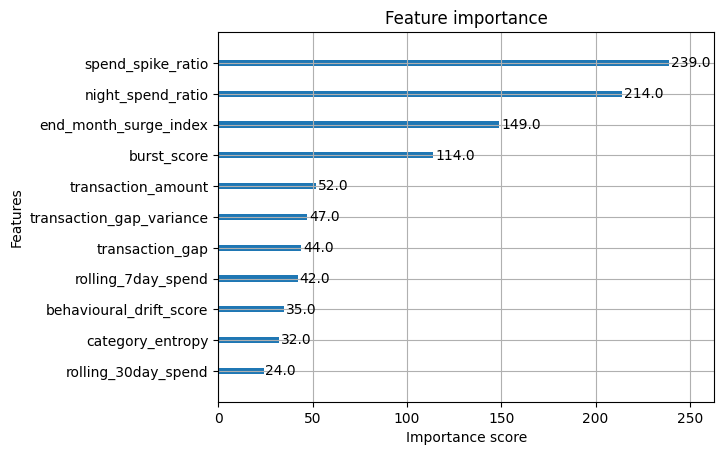

In [25]:
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()

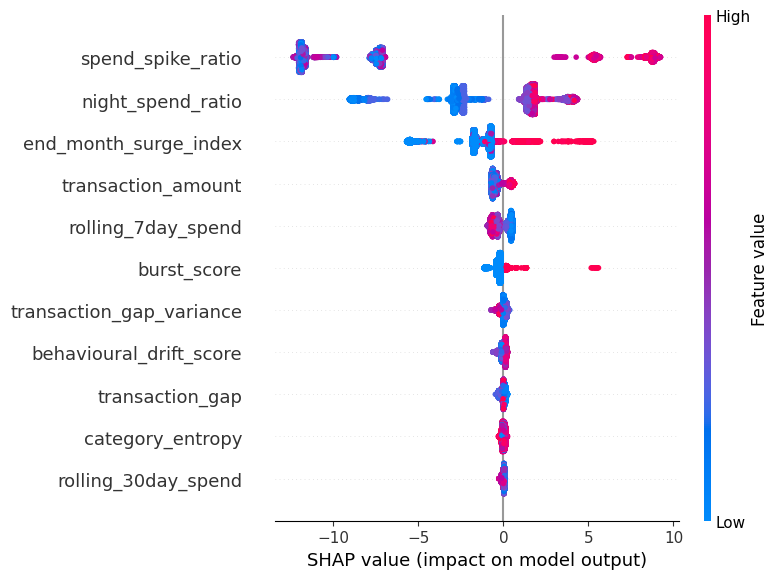

In [26]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [27]:
import joblib
joblib.dump(model, "risk_model.pkl")

['risk_model.pkl']

In [28]:
df.to_csv("transactions_processed.csv", index=False)